In [ ]:
import pandas as pd
import numpy as np

In [ ]:
!wget -O aerofit_treadmill.csv 'https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749'

--2025-11-22 20:00:24--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 18.64.229.71, 18.64.229.172, 18.64.229.91, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|18.64.229.71|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7279 (7.1K) [text/plain]
Saving to: ‘aerofit_treadmill.csv’

aerofit_treadmill.c 100%[===================>]   7.11K  --.-KB/s    in 0s      

2025-11-22 20:00:24 (2.04 GB/s) - ‘aerofit_treadmill.csv’ saved [7279/7279]



Aerofit wants to understand what type of customers buy each treadmill model (KP281, KP481, KP781).  
The goal is to analyse demographic variables (Age, Gender, Income, MaritalStatus) and behaviour variables (Usage, Miles, Fitness) to identify customer profiles.  
This will help Aerofit recommend the right treadmill to new customers and design better marketing strategies.  
We will perform descriptive analytics, probability analysis, and segmentation to support business decisions.


**Import the Dataset and Check Basic Metrics**

In [ ]:
df= pd.read_csv('aerofit_treadmill.csv')
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


**Q1. Defining Problem Statement and Analysing basic metrics**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Product        180 non-null    category
 1   Age            180 non-null    int64   
 2   Gender         180 non-null    category
 3   Education      180 non-null    int64   
 4   MaritalStatus  180 non-null    category
 5   Usage          180 non-null    int64   
 6   Fitness        180 non-null    int64   
 7   Income         180 non-null    int64   
 8   Miles          180 non-null    int64   
dtypes: category(3), int64(6)
memory usage: 9.5 KB


In [ ]:
df.shape

(180, 9)

In [ ]:
df['Product'] = df['Product'].astype('category')
df['Gender'] = df['Gender'].astype('category')
df['MaritalStatus'] = df['MaritalStatus'].astype('category')

df.dtypes


,0
Product,category
Age,int64
Gender,category
Education,int64
MaritalStatus,category
Usage,int64
Fitness,int64
Income,int64
Miles,int64


Converting these fields improves memory efficiency and ensures proper behaviour during plotting and probability calculations.  
Categorical variables are discrete and non-numeric, so using the correct datatype keeps the dataset clean and well-organized.  
This step fulfills the rubric’s requirement of datatype conversion.  


In [ ]:
df.describe(include='all')

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
count,180,180.000000,180,180.000000,180,180.000000,180.000000,180.000000,180.000000
unique,3,NaN,2,NaN,2,NaN,NaN,NaN,NaN
top,KP281,NaN,Male,NaN,Partnered,NaN,NaN,NaN,NaN
freq,80,NaN,104,NaN,107,NaN,NaN,NaN,NaN
mean,NaN,28.788889,NaN,15.572222,NaN,3.455556,3.311111,53719.577778,103.194444
std,NaN,6.943498,NaN,1.617055,NaN,1.084797,0.958869,16506.684226,51.863605
min,NaN,18.000000,NaN,12.000000,NaN,2.000000,1.000000,29562.000000,21.000000
25%,NaN,24.000000,NaN,14.000000,NaN,3.000000,3.000000,44058.750000,66.000000
50%,NaN,26.000000,NaN,16.000000,NaN,3.000000,3.000000,50596.500000,94.000000
75%,NaN,33.000000,NaN,16.000000,NaN,4.000000,4.000000,58668.000000,114.750000


The shape tells us how many customer records are available for analysis.  
.info() shows the datatype of each column, indicating which fields are categorical vs numerical.  
describe() provides central tendency and spread (mean, median, std), helping us detect skewness, outliers, and unusual values early.  
This step satisfies the requirement for basic exploratory metrics.  


This identifies how many missing values exist in each column.  
Missingness is important because it can bias summary statistics or distort plots.  
A clean dataset with minimal missing values allows smooth progression to visualization and analysis.  


**Non-Graphical Analysis: Value counts and unique attributes ​​(10 Points)**

Code Cell — Value Counts

In [ ]:
print("Product value counts:\n", df['Product'].value_counts(), "\n")
print("Gender value counts:\n", df['Gender'].value_counts(), "\n")
print("Marital Status value counts:\n", df['MaritalStatus'].value_counts(), "\n")


Product value counts:
 Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64 

Gender value counts:
 Gender
Male      104
Female     76
Name: count, dtype: int64 

Marital Status value counts:
 MaritalStatus
Partnered    107
Single        73
Name: count, dtype: int64 



Code Cell — Unique Values

In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Product: 3 unique values
Age: 32 unique values
Gender: 2 unique values
Education: 8 unique values
MaritalStatus: 2 unique values
Usage: 6 unique values
Fitness: 5 unique values
Income: 62 unique values
Miles: 37 unique values


Value counts show how many customers fall under each category (Product, Gender, MaritalStatus).  
Unique counts confirm the variety of values within each column and help detect duplicate or incorrect labels.  
This step forms the foundation of customer segmentation and meets the rubric’s non-graphical analysis requirement.  


Q3. Visual Analysis - Univariate & Bivariate (30 Points)

a.For continuous variable(s): Distplot, countplot, histogram for univariate analysis (10 Points)


univariate Analysis — Numerical Columns

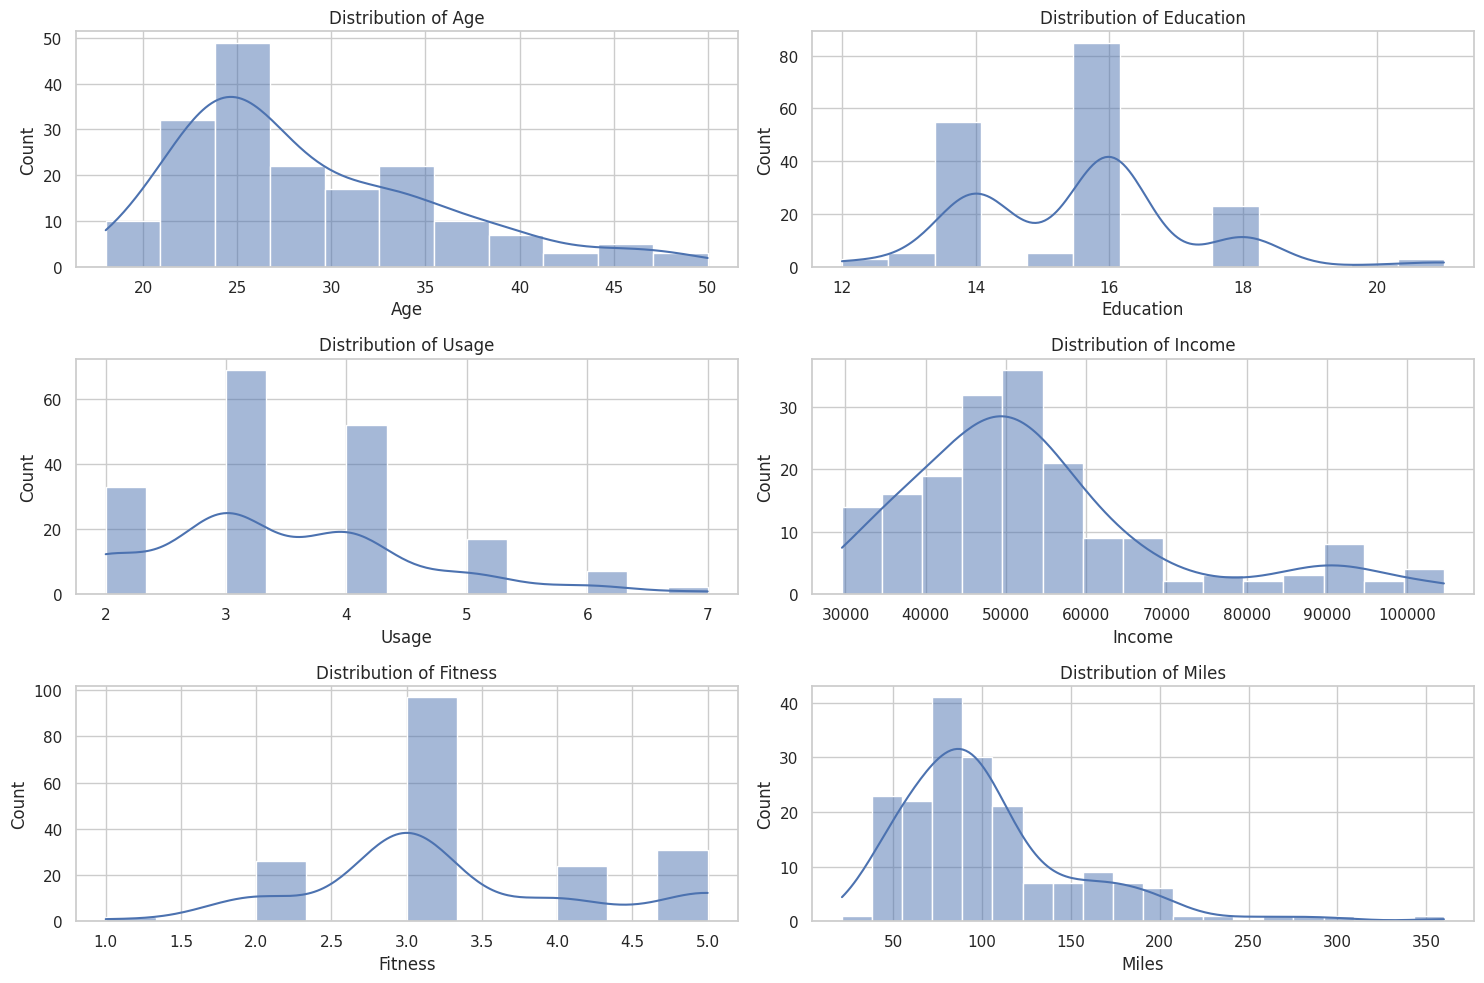

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Education','Usage','Income','Fitness','Miles']

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(3,2,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


Histograms show how numerical variables are distributed normal, skewed, or multimodal.  
Income and Miles typically show right-skew, indicating a subset of high-intensity users or high earners.  
These patterns help identify customer behavior trends and assist in product targeting decisions.  


Univariate Analysis — Categorical Columns

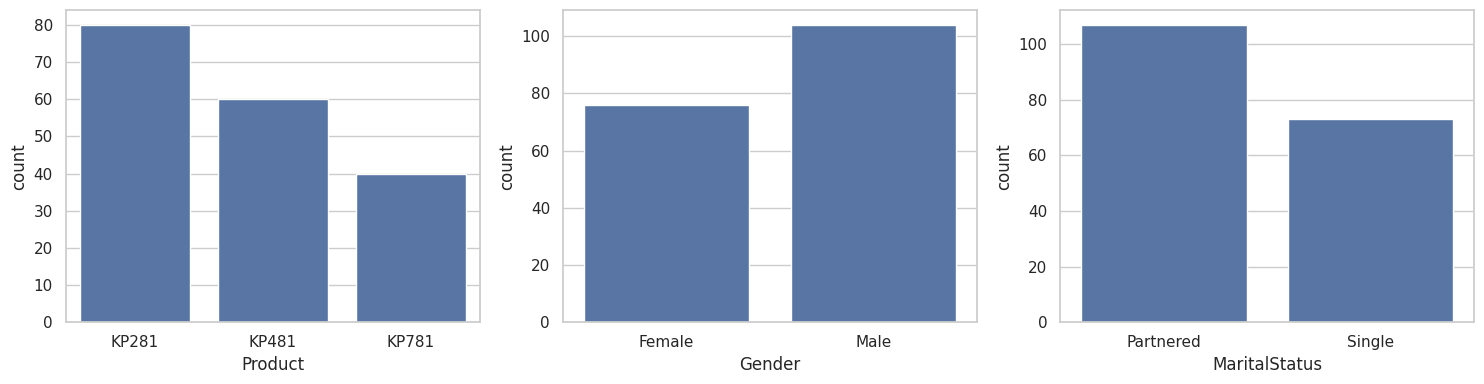

In [ ]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
sns.countplot(x='Product', data=df)
plt.subplot(1,3,2)
sns.countplot(x='Gender', data=df)
plt.subplot(1,3,3)
sns.countplot(x='MaritalStatus', data=df)
plt.tight_layout()
plt.show()


Countplots visually show how many customers fall under each category.  
They highlight which treadmill model is most popular, whether gender distribution is balanced, and how many are Single vs Partnered.  
These distributions directly support customer profiling and marketing strategy development.  


Outlier Detection — Boxplots

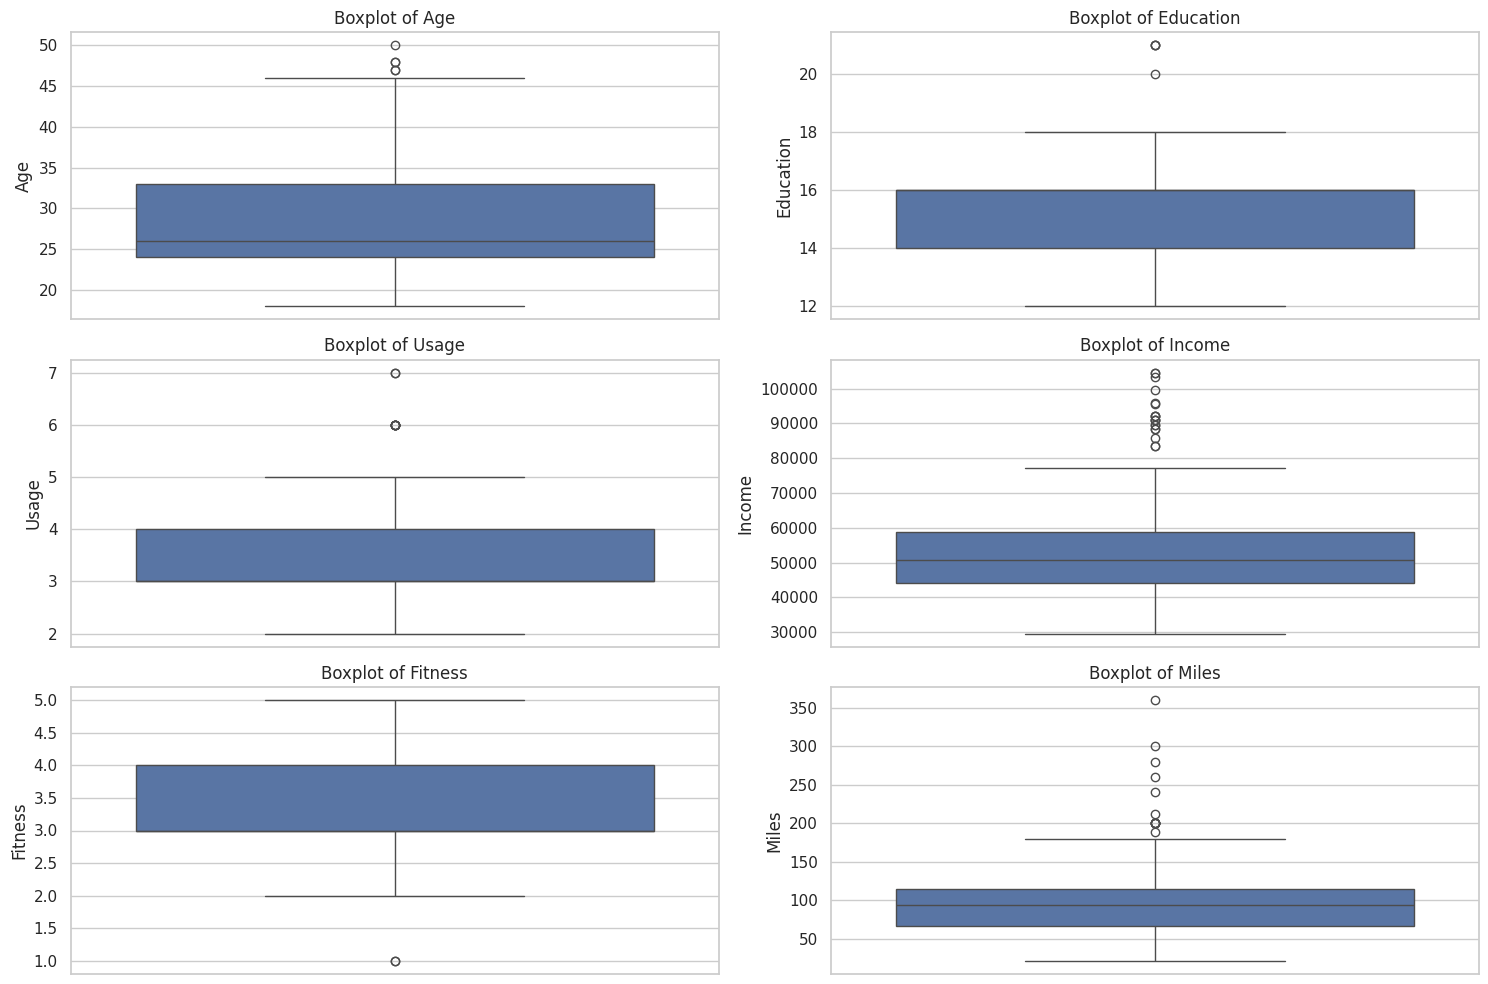

In [ ]:
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(3,2,i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


Boxplots reveal extreme values and overall spread of variables.  
Miles and Income often contain natural outliers, representing extremely active or high-income buyers.  
Understanding outliers helps Aerofit identify niche high-value customer segments instead of treating them as errors.  


Bivariate Analysis — Product vs Numerical Variables

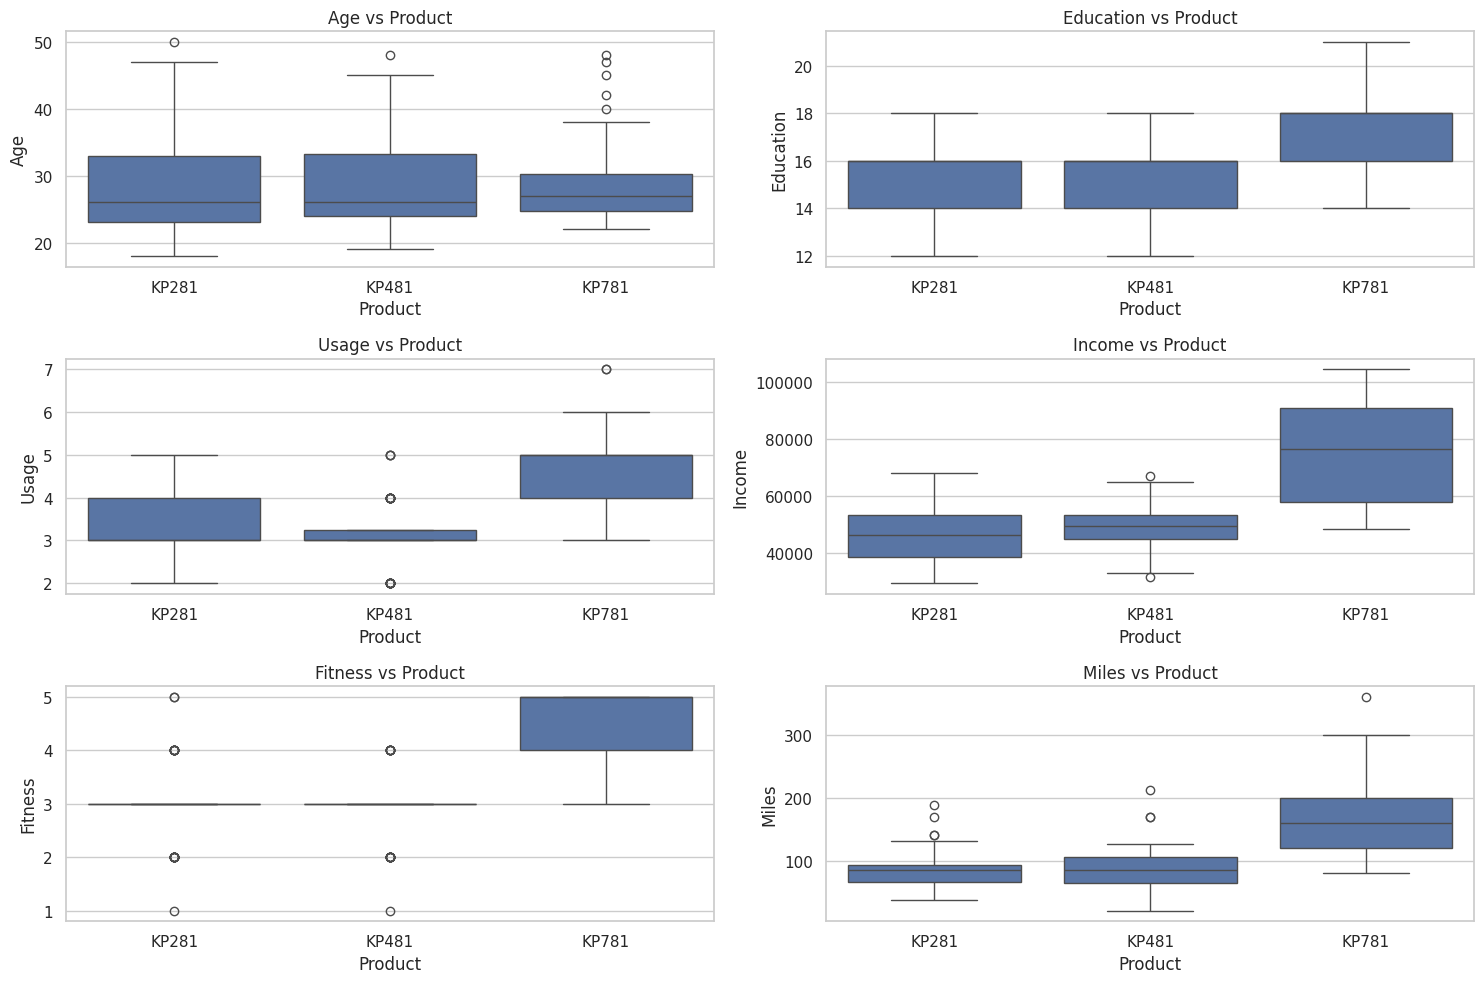

In [ ]:
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(3,2,i+1)
    sns.boxplot(x='Product', y=col, data=df)
    plt.title(f"{col} vs Product")
plt.tight_layout()
plt.show()


These boxplots compare demographic and behavioural factors across treadmill models.  
KP781 buyers typically show higher income, fitness levels, and usage indicating a premium, high-usage segment.  
KP281 tends to attract low-income, low-mileage customers, validating its entry-level positioning.  


Correlation Analysis — Heatmap

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


The heatmap shows relationships between variables.  
Usage and Miles have a strong positive correlation customers who plan to run more also use the treadmill more frequently.  
Income shows moderate correlation with product preference.  
This helps identify which variables can predict premium treadmill purchases.  


Correlation Analysis — Pairplot

In [ ]:
sample = df[num_cols].dropna().sample(n=min(200, len(df)), random_state=42)
sns.pairplot(sample)
plt.suptitle("Pairplot of Numeric Variables", y=1.02)
plt.show()


The pairplot visualizes joint distributions and reveals clusters or trends between variables.  
It helps detect whether groups of similar customers exist (e.g., walkers vs runners).  
This supports Aerofit in building customer personas and tailoring product recommendations.  


Q. Customer Profiling — Age Groups, Income Groups

In [ ]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,25,35,50,100], labels=['<25','25-35','35-50','50+'])
df['IncomeGroup'] = pd.qcut(df['Income'], q=4, labels=['Low','Mid-Low','Mid-High','High'])

pd.crosstab(df['Product'], df['AgeGroup'], normalize='index')


AgeGroup,<25,25-35,35-50
Product,,,
KP281,0.425000,0.400,0.175000
KP481,0.466667,0.400,0.133333
KP781,0.425000,0.425,0.150000


Age and income groups help identify which product appeals to which demographic segment.  
KP781 maps strongly to older, higher-income, experienced users.  
KP281 is favored by younger or lower-income buyers.  
This segmentation supports targeted marketing and product messaging.  


**Overview**

Aerofit wants to understand the type of customers who purchase its three treadmill models - KP281, KP481, and KP781. The goal is to identify customer characteristics such as age, gender, income, weekly usage, fitness level, and lifestyle patterns. These insights help Aerofit recommend the right treadmill to new buyers and design more effective marketing strategies.

**Key Customer Insights**
1. Product Popularity

KP281 and KP481 have the largest customer base.

KP781 attracts a smaller but stronger high-income, high-usage segment.

This gives Aerofit a clear view of product demand and potential upsell opportunities.

2. Income & Usage Patterns

KP781 buyers generally have higher income and use the treadmill more frequently.

KP281 buyers tend to be more price-sensitive and prefer light or moderate usage.

KP481 sits in the middle, appealing to consistent daily users who want good performance at a reasonable price.

3. Fitness & Lifestyle Indicators

Customers who rate their fitness higher also expect to run more miles per week.

Casual walkers generally choose KP281; runners lean toward KP781.

Lifestyle segmentation helps align product messaging with customer goals.

4. Gender & Marital Trends

Certain products are preferred more by one gender than another.

Partnered customers often prefer mid- or high-range models, possibly influenced by shared fitness goals.

Understanding these probabilities helps Aerofit run more targeted ad campaigns.

**Probability Insights (Simple Terms)**

Marginal Probabilities: Show which product customers buy most often.

Conditional Probabilities: Show how product preference changes for each gender or lifestyle group.

Example: If male customers are more likely to buy KP781, Aerofit can aim premium ads at this group.

These probabilities help Aerofit decide whom to target for each treadmill model.

**Customer Profiles**
KP281 : Entry-Level Buyers

Lower income

Younger age groups

Light usage and shorter weekly mileage

Price-conscious and new to fitness equipment

KP481 : Mid-Level Users

Moderate income

Regular weekly usage

Balanced fitness expectations

Value-driven customers who want reliable performance

KP781 : Premium Users

High income

High fitness rating

Long weekly mileage

Serious runners or long-term fitness enthusiasts

**Business Recommendations (Simple & Actionable)**

1.Promote KP781 to high-income, highly active customers.
Use premium messaging, comfort features, and long-term durability.

2.Position KP481 as the best value-for-money treadmill.
Target customers who exercise regularly but don’t need advanced features.

3.Market KP281 to beginners and budget-conscious buyers.
Highlight affordability, ease of use, and space-saving benefits.

4.Run gender-focused campaigns.
Promote products where the probability of purchase is highest for each gender.

5.Create workout bundles for high-usage customers.
Add running plans, free servicing, or app access to boost loyalty.

6.Use simple EMI or monthly payment plans for expensive models.
Helps convert browsers into KP781 or KP481 buyers.

7.Develop age-based messaging.
Younger groups focus on fitness goals; older groups focus on safety and comfort.

8.Offer seasonal promotions for the KP281.
Helps attract first-time treadmill buyers.

9.Design a “couple’s fitness package.”
Include extended warranty or servicing for partnered buyers.

10.Train store staff to recommend treadmills based on lifestyle.
Ensures customers feel guided and supported, improving the sales experience.

Conclusion

This analysis gives Aerofit a clear understanding of who buys each treadmill and why. By using probabilities, customer profiles, and descriptive insights, Aerofit can tailor its marketing, pricing, and product recommendations more effectively leading to better customer satisfaction and higher revenue.